In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [3]:
#load model
hddm_id_m0_acc = hddm.load('hddm_id_m0_acc_diff.hddm')
hddm_id_m1_choice = hddm.load('hddm_id_m1_choice_diff.hddm')
hddmStim_vflip_dc_m1 = hddm.load('hddmStim_vflip_dc_m1.hddm')
hddmStim_zflip_m1 = hddm.load('hddmStim_zflip_m1_diff.hddm')
hddmReg_id_m0_acc = hddm.load('hddmReg_id_m0_acc_diff.hddm')
hddmReg_id_m2_choice = hddm.load('hddmReg_id_m2_choice_diff.hddm')
hddmReg_stim_vflip_dc_m2 = hddm.load('hddmReg_stim_vflip_dc_m2.hddm')
hddmReg_stim_vflip_m3 = hddm.load('hddmReg_stim_vflip_m3_diff.hddm')
hddmReg_stim_zflip_m2 = hddm.load('hddmReg_stim_zflip_m2_diff.hddm')

In [5]:
models = {
    'Base_acc(DIC = -13991.69)': hddm_id_m0_acc,
    'Base_choice(DIC = -13992.65)': hddm_id_m1_choice,
    'Stim_choice_vflip(DIC = -13504.81)': hddmStim_vflip_dc_m1,
    'Stim_acc_zflip(DIC = -13468.68)': hddmStim_zflip_m1,
    'Reg_acc(DIC = -13998.58)': hddmReg_id_m0_acc,
    'Reg_choice(DIC = -13386.62)': hddmReg_id_m2_choice,
    'Reg_choice_vflip_coef(DIC = -13450.38)': hddmReg_stim_vflip_dc_m2,
    'Reg_choice_vflip_link(DIC = -13419.68)': hddmReg_stim_vflip_m3,
    'Reg_acc_zflip(DIC = -13387.98)': hddmReg_stim_zflip_m2,
}

Base_acc(DIC = -13991.69): matched
Base_choice(DIC = -13992.65): matched
Stim_choice_vflip(DIC = -13504.81): matched
Reg_acc(DIC = -13998.58): matched
Reg_choice(DIC = -13386.62): matched
Reg_choice_vflip_coef(DIC = -13450.38): matched
Reg_choice_vflip_link(DIC = -13419.68): matched


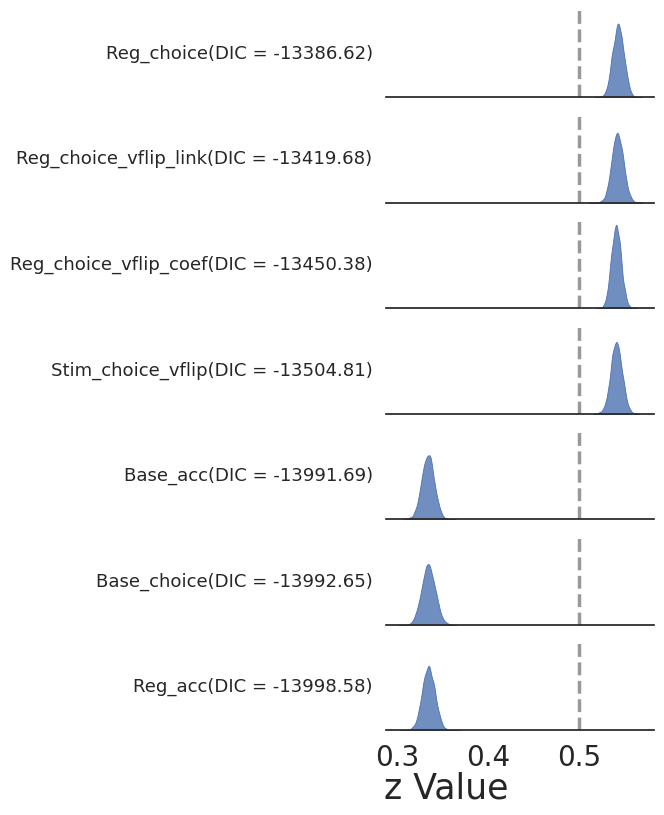

In [8]:
# ================= 图：z(单 z 模型,7 个) =================
models_z = {
    'Base_acc(DIC = -13991.69)': hddm_id_m0_acc,
    'Base_choice(DIC = -13992.65)': hddm_id_m1_choice,
    'Stim_choice_vflip(DIC = -13504.81)': hddmStim_vflip_dc_m1,
    'Reg_acc(DIC = -13998.58)': hddmReg_id_m0_acc,
    'Reg_choice(DIC = -13386.62)': hddmReg_id_m2_choice,
    'Reg_choice_vflip_coef(DIC = -13450.38)': hddmReg_stim_vflip_dc_m2,
    'Reg_choice_vflip_link(DIC = -13419.68)': hddmReg_stim_vflip_m3,
}

target_param_variants_single = {
    'z': ['z', 'z_Intercept'],   # 基础/StimCoding → 'z'；Regression → 'z_Intercept'
}

RED_Z = None   # 原文献 identity task 的 z 值，填了才画红线，例如 RED_Z = 0.60

# 若 extract_param_stats 已在上一个 cell 定义过，可跳过这个 def
def extract_param_stats(model_obj, model_name, dic_value, target_param_variants):
    try:
        stats = model_obj.gen_stats()
    except Exception:
        return pd.DataFrame()
    all_names = stats.index.tolist()
    rows = []
    for display_name, variants in target_param_variants.items():
        raw_name = next((v for v in variants if v in all_names), None)
        if raw_name is None:
            continue
        r = stats.loc[raw_name]
        rows.append({
            'Model': model_name,
            'Parameter': display_name,
            'mean': r['mean'],
            'std': (r['97.5q'] - r['2.5q']) / (2 * 1.96),
            'DIC': dic_value,
        })
    return pd.DataFrame(rows)

all_stats = []
for name, obj in models_z.items():
    dic = getattr(obj, 'dic', None)
    s = extract_param_stats(obj, name, dic, target_param_variants_single)
    if not s.empty:
        all_stats.append(s)
        print(f"{name}: matched")
    else:
        print(f"{name}: NO z matched —— 检查参数名")

df_stats_all = pd.concat(all_stats, ignore_index=True)

np.random.seed(42)
samples_list = []
for _, r in df_stats_all.iterrows():
    samples_list.append(pd.DataFrame({
        'Model': r['Model'], 'Parameter': r['Parameter'],
        'value': np.random.normal(r['mean'], r['std'], 5000), 'DIC': r['DIC']}))
df_samples = pd.concat(samples_list, ignore_index=True)

model_order = (df_samples[['Model', 'DIC']].drop_duplicates()
                .sort_values('DIC', ascending=False)['Model'].tolist())
df_samples['Model'] = pd.Categorical(df_samples['Model'], categories=model_order, ordered=True)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df_samples, row='Model', aspect=6, height=1.2, sharex=True, sharey=True)
g.map_dataframe(sns.kdeplot, x='value', fill=True, alpha=0.8, linewidth=0.6)
g.set_titles("")
g.set_axis_labels("", "")
g.set(yticks=[])
g.despine(left=True)
plt.subplots_adjust(hspace=-0.4)

for ax in g.axes.flat:
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=2.5, alpha=0.8)          # 无偏
    if RED_Z is not None:
        ax.axvline(RED_Z, color='crimson', linestyle='--', linewidth=2.0, alpha=0.9)  # 原文献
    ax.tick_params(axis='x', labelsize=20)

for ax, mn in zip(g.axes[:, 0], model_order):
    ax.text(-0.05, 0.5, mn, transform=ax.transAxes, ha='right', va='center', fontsize=13)

g.fig.text(0.6, 0.02, 'z Value', fontsize=25)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.savefig('Fig/ridge_single_z.svg', format='svg', bbox_inches='tight')
plt.show()

Base_acc(DIC = -13991.69): extract 2 dc parameter
Base_choice(DIC = -13992.65): extract 2 dc parameter
Stim_choice_vflip(DIC = -13504.81): extract 2 dc parameter
Stim_acc_zflip(DIC = -13468.68): extract 2 dc parameter
Reg_acc(DIC = -13998.58): extract 2 dc parameter
Reg_choice(DIC = -13386.62): extract 2 dc parameter
Reg_choice_vflip_coef(DIC = -13450.38): extract 2 dc parameter
Reg_choice_vflip_link(DIC = -13419.68): extract 1 dc parameter
Reg_acc_zflip(DIC = -13387.98): extract 2 dc parameter


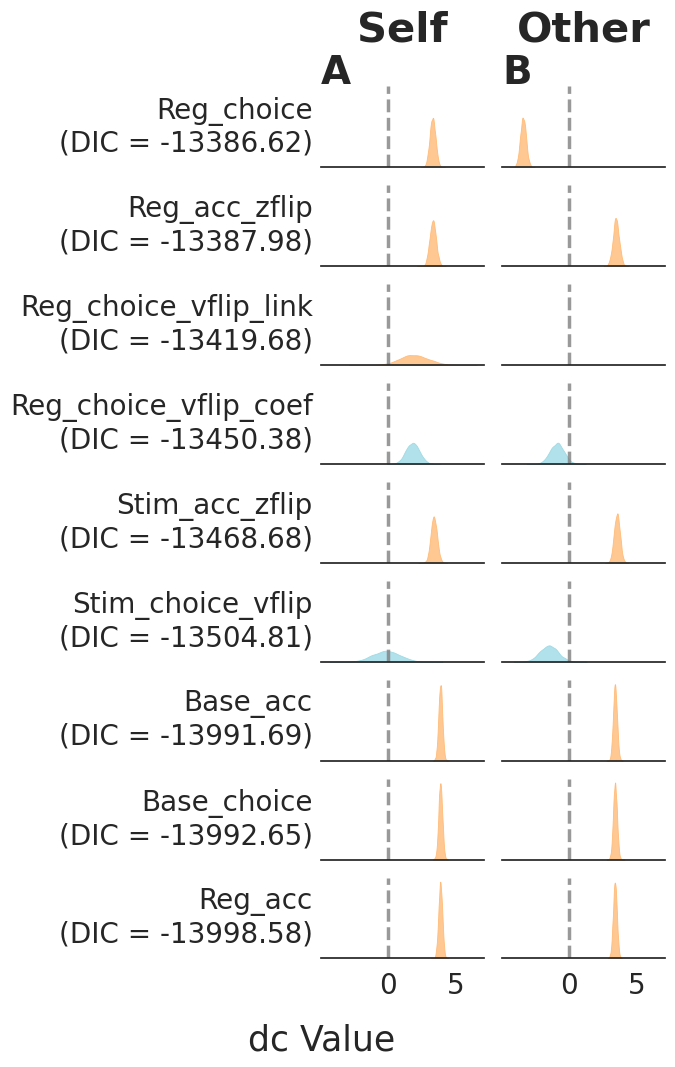

In [9]:
# ======================= 直接提取 dc 参数 =======================
def extract_dc_stats(model_obj, model_name, dic_value):
    try:
        stats = model_obj.gen_stats()
    except Exception:
        return pd.DataFrame()
    all_names = stats.index.tolist()
    variants = {
        'dc(Self)':  ['dc(Self)',  'dc_Intercept(Self)'],
        'dc(Other)': ['dc(Other)', 'dc_Intercept(Other)'],
    }
    rows = []
    for display, vs in variants.items():
        raw = next((v for v in vs if v in all_names), None)
        if raw is None:
            continue
        r = stats.loc[raw]
        rows.append({
            'Model': model_name,
            'Parameter': display,
            'mean': r['mean'],
            'std': (r['97.5q'] - r['2.5q']) / (2 * 1.96),
            'DIC': dic_value,
        })
    return pd.DataFrame(rows)

# ======================= 间接计算 dc(无 dc 参数的模型) =======================
def compute_indirect_dc(model_obj):
    try:
        traces = model_obj.get_traces()
        if not hasattr(traces, 'columns'):          # 若返回 dict，转 DataFrame
            traces = pd.DataFrame(traces)
    except Exception:
        return pd.DataFrame()
    params = traces.columns.tolist()

    def _add(pname, display):
        v = traces[pname].values
        return {
            'Parameter': display,
            'mean': v.mean(),
            'std': (np.percentile(v, 97.5) - np.percentile(v, 2.5)) / (2 * 1.96),
        }

    data = []
    # 情况 1：v(Self.1)/v(Other.0) —— HDDM 与 z_reg 模型的 v (depends_on v~id/stim)
    if 'v(Self.1)' in params and 'v(Other.0)' in params:
        data.append(_add('v(Self.1)', 'dc(Self)'))
        data.append(_add('v(Other.0)', 'dc(Other)'))
    # 情况 2：v_Intercept(Self.1)/v_Intercept(Other.0) —— Regression v~id/stim
    elif 'v_Intercept(Self.1)' in params and 'v_Intercept(Other.0)' in params:
        data.append(_add('v_Intercept(Self.1)', 'dc(Self)'))
        data.append(_add('v_Intercept(Other.0)', 'dc(Other)'))
    # 情况 3：v_Intercept(Self)/v_Intercept(Other) —— Regression v~id (choice coding)
    elif 'v_Intercept(Self)' in params and 'v_Intercept(Other)' in params:
        data.append(_add('v_Intercept(Self)', 'dc(Self)'))
        data.append(_add('v_Intercept(Other)', 'dc(Other)'))
    # 情况 4：v flip link —— v_C(stim)[T.1] 等
    elif 'v_C(stim)[T.1]' in params:
        if 'v_id[Self]' in params:
            data.append(_add('v_C(stim)[T.1]', 'dc(Self)'))
        if 'v_id[T.Other]:C(stim)[T.1]' in params and 'v_id[Other]' in params:
            v_other = traces['v_C(stim)[T.1]'].values + traces['v_id[T.Other]:C(stim)[T.1]'].values
            data.append({
                'Parameter': 'dc(Other)',
                'mean': v_other.mean(),
                'std': (np.percentile(v_other, 97.5) - np.percentile(v_other, 2.5)) / (2 * 1.96),
            })
    return pd.DataFrame(data)

# ======================= 提取所有模型的 dc =======================
all_stats_list = []
for model_name, model_obj in models.items():
    dic_val = getattr(model_obj, 'dic', None)
    if dic_val is None:
        match = re.search(r'DIC\s*=\s*([-\d\.]+)', model_name)
        dic_val = float(match.group(1)) if match else float('inf')

    df_stats = extract_dc_stats(model_obj, model_name, dic_val)   # 先直接
    if df_stats.empty:
        df_ind = compute_indirect_dc(model_obj)                    # 再间接
        if not df_ind.empty:
            df_ind['Model'] = model_name
            df_ind['DIC'] = dic_val
            df_stats = df_ind

    if not df_stats.empty:
        all_stats_list.append(df_stats)
        print(f"{model_name}: extract {len(df_stats)} dc parameter")
    else:
        print(f"{model_name}: no dc parameter")

if not all_stats_list:
    raise ValueError("No statistics extracted from any model.")
df_stats_all = pd.concat(all_stats_list, ignore_index=True)

# ======================= 模拟后验样本 =======================
np.random.seed(42)
simulated_samples = []
for _, row in df_stats_all.iterrows():
    samples = np.random.normal(loc=row['mean'], scale=row['std'], size=5000)
    simulated_samples.append(pd.DataFrame({
        'Model': row['Model'], 'Parameter': row['Parameter'],
        'value': samples, 'DIC': row['DIC'],
    }))
df_samples = pd.concat(simulated_samples, ignore_index=True)

# ======================= 模型排序 + 命名 =======================
def format_model_name(name):
    match = re.match(r'^(.*?)(\(DIC\s*=\s*[-\d\.]+\))$', name)
    if match:
        return f"{match.group(1)}\n{match.group(2)}"
    return name

model_dic_pairs = sorted(
    [(mn, float(re.search(r'DIC\s*=\s*([-\d\.]+)', mn).group(1)))
    for mn in df_samples['Model'].unique()],
    key=lambda x: x[1], reverse=True,
)
model_order = [format_model_name(mn) for mn, _ in model_dic_pairs]

df_samples['Model_Display'] = df_samples['Model'].apply(format_model_name)
df_samples['Model_Display'] = pd.Categorical(df_samples['Model_Display'], categories=model_order, ordered=True)

def get_model_type(model_name):
    base_name = model_name.split('\n')[0]
    return 'direct' if base_name in ['Reg_choice_vflip_coef', 'Stim_choice_vflip'] else 'other'

df_samples['Model_Type'] = df_samples['Model_Display'].apply(get_model_type)

# ======================= 画图 =======================
TARGET_PARAMS = ['dc(Self)', 'dc(Other)']
df_plot = df_samples[df_samples['Parameter'].isin(TARGET_PARAMS)].copy()
df_plot['Parameter'] = pd.Categorical(df_plot['Parameter'], categories=TARGET_PARAMS, ordered=True)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
palette = {'other': '#ffbb78', 'direct': '#9edae5'}

g = sns.FacetGrid(
    df_plot, row='Model_Display', col='Parameter', hue='Model_Type',
    palette=palette, aspect=3, height=1.2, sharex=True, sharey=True,
)
g.map_dataframe(sns.kdeplot, x='value', fill=True, alpha=0.8, linewidth=0.6)
g.set_titles("")
g.set_axis_labels("", "")
g.set(yticks=[])
g.despine(left=True)
plt.subplots_adjust(hspace=-0.4)

for ax in g.axes.flat:
    ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.tick_params(axis='x', labelsize=20)

# 原文献红线：2 条件两个值，查了再填；不填就 None
red_line_positions = None   # 例：[0.04, 0.13]
if red_line_positions is not None:
    for col_idx in range(g.axes.shape[1]):
        for row_idx in range(g.axes.shape[0]):
            g.axes[row_idx, col_idx].axvline(red_line_positions[col_idx],
                                            color='crimson', linestyle='--', linewidth=2.0, alpha=0.9)

col_titles = ['Self', 'Other']
for ax, title in zip(g.axes[0], col_titles):
    ax.set_title(title, fontsize=30, fontweight='bold', pad=33)

for i, ax in enumerate(g.axes[0]):
    ax.text(0, 1.4, string.ascii_uppercase[i], transform=ax.transAxes,
            fontsize=28, fontweight='bold', va='top', ha='left')

for ax, model_name in zip(g.axes[:, 0], model_order):
    ax.text(-0.05, 0.5, model_name, transform=ax.transAxes,
            ha='right', va='center', fontsize=20)

g.fig.text(0.60, 0, 'dc Value', ha='right', fontsize=25)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.savefig('Parameter_ridgeplot_dc.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()